In [ ]:
import os
import sys
import subprocess
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import gc

# ==========================================
# 0. GPU Configuration
# ==========================================
# [Critical] GPU must be set before importing torch!
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

# ==========================================
# 1. Install missing packages automatically
# ==========================================
packages_to_install = []

try: import open_clip
except ImportError: packages_to_install.append("open_clip_torch")
try: import huggingface_hub
except ImportError: packages_to_install.append("huggingface_hub")
try: import torch_pruning as tp
except ImportError: packages_to_install.append("torch-pruning")
try: import scipy
except ImportError: packages_to_install.append("scipy")
try: import torchvision
except ImportError: packages_to_install.append("torchvision")
try: import matplotlib
except ImportError: packages_to_install.append("matplotlib")

if packages_to_install:
    print(f"Installing missing packages: {packages_to_install}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *packages_to_install])

'''
If raising erro, just deleted this line and
download https://github.com/ShaowuChen/Optimal_Brain_Connection/blob/main/Selfmake_Importance.py

'''
# Download the specific criterion file from the official repo if not present
# if not os.path.exists("Selfmake_Importance.py"):
#     print("Downloading Selfmake_Importance.py from the official repository...")
#     url = "https://raw.githubusercontent.com/ShaowuChen/Optimal_Brain_Connection/main/Selfmake_Importance.py"
#     urllib.request.urlretrieve(url, "Selfmake_Importance.py")
sys.path.append('../')


import open_clip
import torch_pruning as tp
import torchvision
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader
import torch
import torch.nn.functional as F
from Selfmake_Importance import GroupJacobianImportance_accumulate, WHCImportance

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}, Current CUDA Device: {torch.cuda.current_device()}")

# ==========================================
# 2. HQ-CLIP Model and Dataset Definition
# ==========================================
MODEL_NAME = "hf-hub:zhixiangwei/vlm150m-hqclip-large-vitb16"
SHORT_NAME = "HQ-CLIP-ViT-B16"
BATCH_SIZE_TEST = 64
BATCH_SIZE_TRAIN = 32
DATA_ROOT = "/data/csw/dataset"

print("Loading HQ-CLIP preprocessing...")
_, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, device="cpu")
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

print("Preparing CIFAR100 dataset...")
test_dataset = CIFAR100(root=DATA_ROOT, train=False, download=False, transform=preprocess)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_TEST, shuffle=False, num_workers=2)

train_dataset = CIFAR100(root=DATA_ROOT, train=True, download=False, transform=preprocess)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True, num_workers=2)

classes = test_dataset.classes
text_inputs = tokenizer([f"a photo of a {c}" for c in classes]).to(device)

def evaluate(eval_model, dataloader):
    """Zero-shot Evaluation on CIFAR-100"""
    eval_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        text_features = eval_model.encode_text(text_inputs)
        text_features = F.normalize(text_features, dim=-1)
        logit_scale = eval_model.logit_scale.exp()

        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            image_features = eval_model.encode_image(imgs)
            image_features = F.normalize(image_features, dim=-1)

            logits_per_image = logit_scale * image_features @ text_features.T
            _, predicted = logits_per_image.max(1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return correct / total

example_image = torch.randn(1, 3, 224, 224).to(device)
example_text = tokenizer(["a photo of a cat"]).to(device)
example_inputs = (example_image, example_text)

def get_model_and_pruner(importance_criterion, target_sparsity, pruning_steps):
    """Initialize a fresh model and pruner for each experiment trial"""
    model, _, _ = open_clip.create_model_and_transforms(MODEL_NAME, device=device)
    model = model.float()
    model.eval()

    for p in model.parameters():
        p.requires_grad_(True)

    ignored_layers = []
    for m in model.modules():
        if isinstance(m, torch.nn.Embedding):
            ignored_layers.append(m)

    if hasattr(model, 'visual'):
        if hasattr(model.visual, 'attnpool'):
            ignored_layers.append(model.visual.attnpool)
        if hasattr(model.visual, 'ln_post'):
            ignored_layers.append(model.visual.ln_post)

    if hasattr(model, 'ln_final'):
        ignored_layers.append(model.ln_final)
    elif hasattr(model, 'text') and hasattr(model.text, 'ln_final'):
        ignored_layers.append(model.text.ln_final)

    unwrapped_parameters = []
    if hasattr(model, 'text_projection') and model.text_projection is not None:
        unwrapped_parameters.append((model, 'text_projection'))
    elif hasattr(model, 'text') and hasattr(model.text, 'proj') and model.text.proj is not None:
        unwrapped_parameters.append((model.text, 'proj'))
    if hasattr(model, 'visual') and hasattr(model.visual, 'proj') and model.visual.proj is not None:
        unwrapped_parameters.append((model.visual, 'proj'))

    pruner = tp.pruner.MetaPruner(
        model,
        example_inputs=example_inputs,
        importance=importance_criterion,
        global_pruning=True,
        ch_sparsity=target_sparsity,
        iterative_steps=pruning_steps,
        ignored_layers=ignored_layers,
        unwrapped_parameters=unwrapped_parameters
    )
    return model, pruner

def count_parameters(model):
    """Count remaining MACs and Parameters"""
    macs, nparams = tp.utils.count_ops_and_params(model, example_inputs)
    return macs, nparams

print("Evaluating Baseline Model...")
base_model, _ = get_model_and_pruner(tp.importance.MagnitudeImportance(p=2), 0.5, 10)
orig_acc = evaluate(base_model, test_loader)
orig_macs, orig_params = count_parameters(base_model)
print(f"--> Baseline Accuracy ({SHORT_NAME}): {orig_acc * 100:.2f}%, Params: {orig_params/1e6:.2f}M")
del base_model
torch.cuda.empty_cache()

# ==========================================
# 3. Running Experiments
# ==========================================
target_sparsity = 0.9
pruning_steps = 18 
num_batches_for_grad = 50

criteria_names = ['L1', 'FPGM', 'WHC', 'Random', 'Taylor', 'Jacobian']

# Lists to store results from ALL trials
results_acc = {name: [] for name in criteria_names}
results_macs = {name: [] for name in criteria_names}
results_params = {name: [] for name in criteria_names}

for crit_name in criteria_names:
    print(f"\n{'='*60}\nStarting Experiments for Criterion: {crit_name}\n{'='*60}")
    
    # Stochastic criteria run 5 times; Deterministic criteria run 1 time
    num_trials = 5 if crit_name in ['Taylor', 'Jacobian'] else 1
    
    for trial in range(num_trials):
        print(f"\n>>> Trial {trial + 1} / {num_trials} for {crit_name} <<<")
        
        # Initialize importance criterion
        if crit_name == 'L1':
            imp = tp.importance.MagnitudeImportance(p=1, group_reduction='sum', normalizer=None)
        elif crit_name == 'BN':
            imp = tp.importance.BNScaleImportance(group_reduction='sum', normalizer=None)
        elif crit_name == 'FPGM':
            imp = tp.importance.FPGMImportance(group_reduction='sum', normalizer=None)
        elif crit_name == 'WHC':
            imp = WHCImportance(group_reduction='sum', normalizer=None)
        elif crit_name == 'Random':
            imp = tp.importance.RandomImportance()
        elif crit_name == 'Taylor':
            imp = tp.importance.TaylorImportance(group_reduction='sum', normalizer=None)
        elif crit_name == 'Jacobian':
            imp = GroupJacobianImportance_accumulate(group_reduction='sum', normalizer=None)

        # Get a fresh model and Pruner
        model, pruner = get_model_and_pruner(imp, target_sparsity, pruning_steps)
        
        trial_acc_list = [orig_acc]
        trial_macs_list = [orig_macs]
        trial_params_list = [orig_params]

        # Start iterative pruning loop
        for step in range(pruning_steps):
            current_sparsity_ratio = (step + 1) * (target_sparsity / pruning_steps)
            print(f"--- Step {step+1}/{pruning_steps} (~{current_sparsity_ratio*100:.1f}%) ---")

            if crit_name in ['Taylor', 'Jacobian']:
                model.eval()
                if crit_name == 'Jacobian':
                    if hasattr(imp, 'zero_score'): imp.zero_score()
                    if hasattr(imp, 'zero_grad'): imp.zero_grad()
                if crit_name == 'Taylor':
                    model.zero_grad()

                for k, (imgs, lbls) in enumerate(train_loader):
                    if k >= num_batches_for_grad:
                        break
                    imgs = imgs.to(device)
                    batch_texts = [f"a photo of a {classes[l]}" for l in lbls]
                    text_toks = tokenizer(batch_texts).to(device)

                    if crit_name == 'Jacobian':
                        model.zero_grad()

                    image_features, text_features, logit_scale = model(imgs, text_toks)
                    image_features = F.normalize(image_features, dim=-1)
                    text_features = F.normalize(text_features, dim=-1)

                    logits_per_image = logit_scale * image_features @ text_features.T
                    logits_per_text = logits_per_image.T
                    labels = torch.arange(len(imgs)).to(device)
                    
                    loss = (F.cross_entropy(logits_per_image, labels) + F.cross_entropy(logits_per_text, labels)) / 2
                    loss.backward()

                    if crit_name == 'Jacobian':
                        imp.accumulate_grad(model)
                        imp.accumulate_score(model)
                        torch.cuda.empty_cache()

            pruner.step()
            pruned_acc = evaluate(model, test_loader)
            pruned_macs, pruned_params = count_parameters(model)

            trial_acc_list.append(pruned_acc)
            trial_params_list.append(pruned_params)
            trial_macs_list.append(pruned_macs)
            
            print(f"Result: {crit_name} Step {step+1} -> MACs Left {pruned_macs/1e9:.2f}G, Params Left: {pruned_params/1e6:.2f}M, Accuracy: {pruned_acc * 100:.2f}%")

        # Store current trial results
        results_acc[crit_name].append(trial_acc_list)
        results_params[crit_name].append(trial_params_list)
        results_macs[crit_name].append(trial_macs_list)
        
        # Clean up memory after each trial
        del model, pruner
        gc.collect()
        torch.cuda.empty_cache()

print("\nAll experiments completed!")

# ==========================================
# 4. Save results to .npy
# ==========================================
save_dir = "../hqclip/results/ViT/CIFAR100_5times/Both_Brach"
os.makedirs(save_dir, exist_ok=True)

payload = {
    "criteria_names": criteria_names,
    "target_sparsity": target_sparsity,
    "pruning_steps": pruning_steps,
    "orig_acc": orig_acc,
    "orig_macs": orig_macs,
    "orig_params": orig_params,
    # Dimensions vary: [1, steps+1] for deterministic; [10, steps+1] for stochastic
    "results_acc": results_acc,       
    "results_macs": results_macs,     
    "results_params": results_params, 
}

data_path = os.path.join(save_dir, "pruning_experiment_results.npy")
np.save(data_path, payload)


CUDA_VISIBLE_DEVICES = 0


/home/csw/anaconda3/envs/yolo_pruning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda, Current CUDA Device: 0
Loading HQ-CLIP preprocessing...


Preparing CIFAR100 dataset...


/home/csw/anaconda3/envs/yolo_pruning/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


...

Result: Jacobian Step 14 -> MACs Left 12.49G, Params Left: 94.82M, Accuracy: 30.63%
--- Step 15/18 (~75.0%) ---


Result: Jacobian Step 15 -> MACs Left 11.77G, Params Left: 90.57M, Accuracy: 12.72%
--- Step 16/18 (~80.0%) ---


Result: Jacobian Step 16 -> MACs Left 10.97G, Params Left: 86.15M, Accuracy: 2.40%
--- Step 17/18 (~85.0%) ---


Result: Jacobian Step 17 -> MACs Left 10.14G, Params Left: 81.66M, Accuracy: 1.82%
--- Step 18/18 (~90.0%) ---


Result: Jacobian Step 18 -> MACs Left 9.26G, Params Left: 77.07M, Accuracy: 2.09%

All experiments completed!


Generating plots based on reference style...


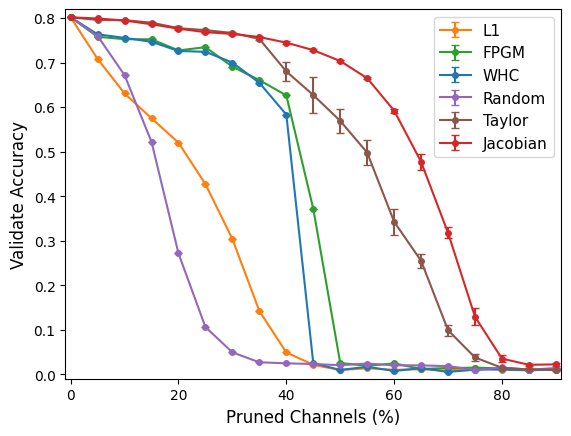

In [2]:

# ==========================================
# 5. Plotting section (Reference Code Style)
# ==========================================

print("Generating plots based on reference style...")

loaded_payload = np.load(data_path, allow_pickle=True).item()

criteria_names = loaded_payload['criteria_names']
target_sparsity = loaded_payload['target_sparsity']
pruning_steps = loaded_payload['pruning_steps']
orig_params = loaded_payload['orig_params']
orig_macs = loaded_payload['orig_macs']

accuracy_records = loaded_payload['results_acc']
params_records = loaded_payload['results_params']
macs_records = loaded_payload['results_macs']

color_map = {
    'WHC': 'C0',
    'L1': 'C1',
    'FPGM': 'C2',
    'Jacobian': 'C3',
    'Random': 'C4',
    'Taylor': 'C5',
    'Hessian': 'C6',
    'BN Scale': 'C7',
    'BN': 'C7',
}

# ---------------------------------------------------------
# Plot 1: Pruned Channels vs Validate Accuracy
# ---------------------------------------------------------
plt.figure()
sparsity_ticks = np.linspace(0, target_sparsity, pruning_steps + 1) * 100 

for criterion in criteria_names:
    # acc_matrix will be shape (1, steps+1) or (10, steps+1)
    acc_matrix = np.array(accuracy_records[criterion]) 
    
    # Calculate mean and std dynamically. 
    # If shape is (1, N), std will naturally become an array of zeros.
    acc_mean = np.mean(acc_matrix, axis=0)             
    acc_std = np.std(acc_matrix, axis=0)               
    
    plt.errorbar(sparsity_ticks, acc_mean, yerr=acc_std, 
                 fmt='o', ms=4, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='-', label=criterion)

plt.xlim(-1, 91)
plt.ylim(-1/100, 82/100)
plt.xlabel('Pruned Channels (%)', fontsize=12)
plt.ylabel('Validate Accuracy', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.savefig(os.path.join(save_dir, 'Propotion_Validate_acc.pdf'), bbox_inches='tight')
plt.show()
plt.close()


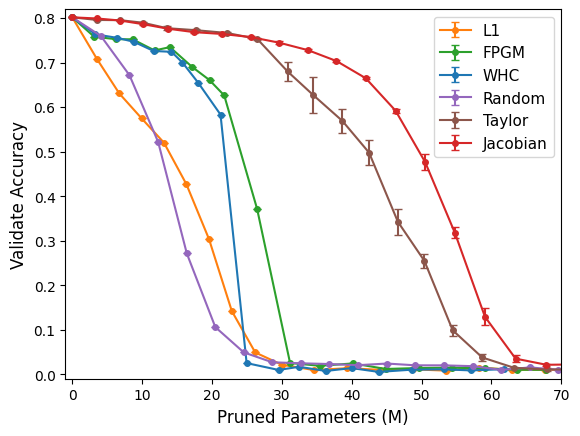

In [3]:
# ---------------------------------------------------------
# Plot 2: Pruned Parameters vs Validate Accuracy
# ---------------------------------------------------------
plt.figure()

for criterion in criteria_names:
    acc_matrix = np.array(accuracy_records[criterion])
    acc_mean = np.mean(acc_matrix, axis=0)
    acc_std = np.std(acc_matrix, axis=0)
    
    params_matrix = np.array(params_records[criterion])
    params_mean = np.mean(params_matrix, axis=0)
    
    # Pruned parameters in Millions
    pruned_params_array = (orig_params - params_mean) / 1e6  
    
    plt.errorbar(pruned_params_array, acc_mean, yerr=acc_std, 
                 fmt='o', ms=4, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='-', label=criterion)

plt.xlim(-1, 70)
plt.ylim(-1/100, 82/100)
plt.xlabel('Pruned Parameters (M)', fontsize=12)
plt.ylabel('Validate Accuracy', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.savefig(os.path.join(save_dir, 'params_Validate_acc.pdf'), bbox_inches='tight')
plt.show()
plt.close()


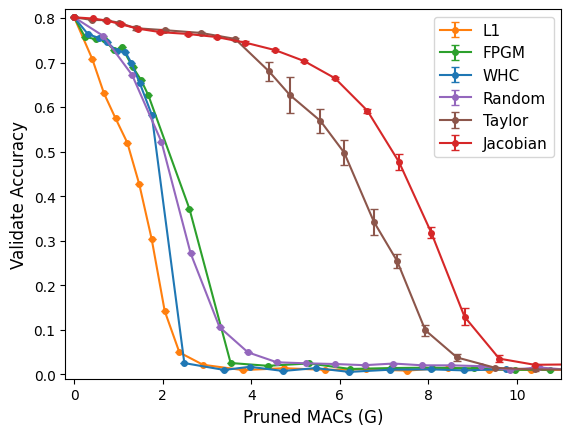

All figures have been successfully plotted and saved to: ../hqclip/results/ViT/CIFAR100_5times/Both_Brach


In [4]:

# ---------------------------------------------------------
# Plot 3: Pruned MACs vs Validate Accuracy
# ---------------------------------------------------------
plt.figure()

for criterion in criteria_names:
    acc_matrix = np.array(accuracy_records[criterion])
    acc_mean = np.mean(acc_matrix, axis=0)
    acc_std = np.std(acc_matrix, axis=0)
    
    macs_matrix = np.array(macs_records[criterion])
    macs_mean = np.mean(macs_matrix, axis=0)
    
    # Pruned MACs in Billions (G)
    pruned_macs_array = (orig_macs - macs_mean) / 1e9  
    
    plt.errorbar(pruned_macs_array, acc_mean, yerr=acc_std, 
                 fmt='o', ms=4, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='-', label=criterion)

plt.xlim(-0.2, 11)
plt.ylim(-1/100, 82/100)
plt.xlabel('Pruned MACs (G)', fontsize=12)
plt.ylabel('Validate Accuracy', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.savefig(os.path.join(save_dir, 'macs_Validate_acc.pdf'), bbox_inches='tight')
plt.show()
plt.close()

print(f"All figures have been successfully plotted and saved to: {save_dir}")

成功加载以下准则的数据: ['L1', 'FPGM', 'WHC', 'Random', 'Taylor', 'Jacobian']


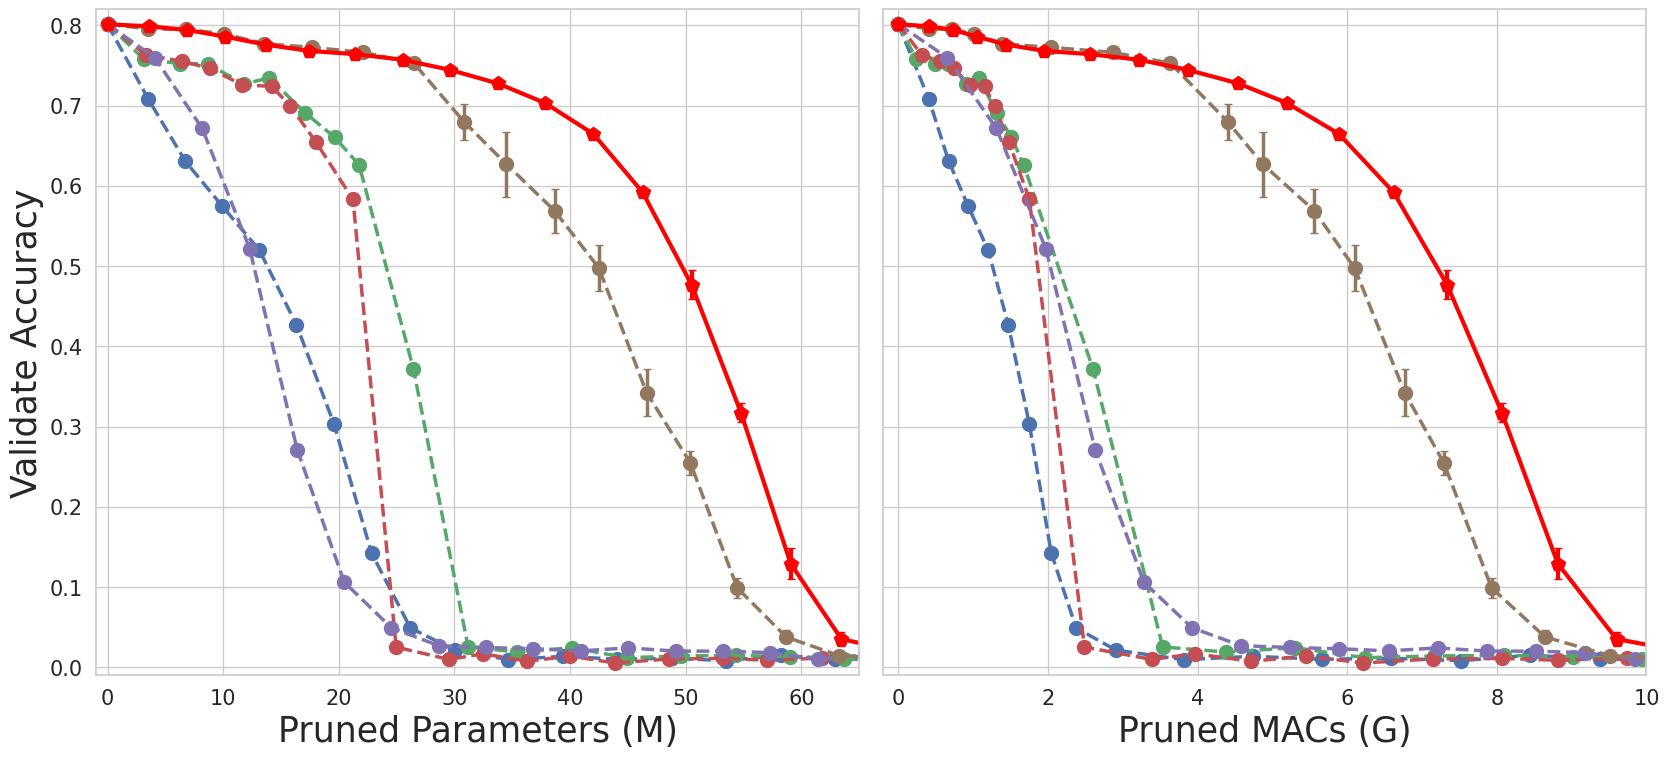

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
save_dir = "../hqclip/results/ViT/CIFAR100_5times/Both_Brach"
os.makedirs(save_dir, exist_ok=True)

# Load data (keep original data logic)
loaded_payload = np.load('/data/csw/optimal_Brain_Pruning2/Optimal_Brain_Pruning/hqclip/results/ViT/CIFAR100_5times/Both_Brach/pruning_experiment_results.npy', allow_pickle=True).item()


# Extract hyperparameters and original baseline metrics
criteria_names = loaded_payload['criteria_names']
orig_params = loaded_payload['orig_params']
orig_macs = loaded_payload['orig_macs']

# Extract recorded performance metrics
accuracy_records = loaded_payload['results_acc']
params_records = loaded_payload['results_params']
macs_records = loaded_payload['results_macs']

print(f"Successfully loaded data for criteria: {criteria_names}")

# ==========================================
# 2. Plot Style & Color Configuration (strictly aligned with reference figure)
# ==========================================
# Enable Seaborn Whitegrid style to match the grid and borderless effect of the reference figure
sns.set(style="whitegrid")

# Color mapping: ensure Jacobian (ours) is prominent red, others use Seaborn default palette
color_map = {
    'L1': 'C0',
    'BN': 'C1',
    'FPGM': 'C2',
    'WHC': 'C3',
    'Random': 'C4',
    'Taylor': 'C5',
    'Hessian': 'C6',
    'Jacobian (ours)': 'red',
    'Jacobian': 'red',
}

# ==========================================
# 3. Generate Combined Plot (1 row, 2 columns, shared Y-axis)
# ==========================================
# Adjust figure size according to reference figure ratio
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
plt.tight_layout(pad=0.0)  # Minimal padding, compact layout

# ---------------------------------------------------------
# Left Plot: Pruned Parameters vs Accuracy
# ---------------------------------------------------------
for criterion in criteria_names:

    acc_matrix = np.array(accuracy_records[criterion])
    acc_mean = np.mean(acc_matrix, axis=0)
    acc_std = np.std(acc_matrix, axis=0)
    
    params_matrix = np.array(params_records[criterion])
    params_mean = np.mean(params_matrix, axis=0)
    
    # Pruned parameters in Millions
    pruned_params_array = (orig_params - params_mean) / 1e6  
    
    # Judge if it is our method (Jacobian)
    is_ours = 'Jacobian' in criterion
    
    # Plot logic fully references the example code
    if is_ours:
        ax_left.errorbar(pruned_params_array, acc_mean, yerr=acc_std, 
                 fmt='p', ms=10, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='-', label=criterion,linewidth=3)
    else:
        ax_left.errorbar(pruned_params_array, acc_mean, yerr=acc_std, 
                 fmt='o', ms=10, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='--', label=criterion,linewidth=2.5)

# Left axis configuration (font size strictly aligned with reference figure)
ax_left.set_xlabel('Pruned Parameters (M)', fontsize=25)
ax_left.set_ylabel('Validate Accuracy', fontsize=25)
ax_left.tick_params(labelsize=15)
ax_left.set_xlim(-1,65)
ax_left.set_ylim(-1/100, 82/100)

# ---------------------------------------------------------
# Right Plot: Pruned MACs vs Accuracy
# ---------------------------------------------------------
for criterion in criteria_names:
    acc_matrix = np.array(accuracy_records[criterion])
    acc_mean = np.mean(acc_matrix, axis=0)
    acc_std = np.std(acc_matrix, axis=0)
    
    macs_matrix = np.array(macs_records[criterion])
    macs_mean = np.mean(macs_matrix, axis=0)
    
    # Pruned MACs in Billions (G)
    pruned_macs_array = (orig_macs - macs_mean) / 1e9  

    is_ours = 'Jacobian' in criterion
    
    # Plot style is identical to left plot, no label added to avoid duplicate legend
    if is_ours:
        ax_right.errorbar(pruned_macs_array, acc_mean, yerr=acc_std, 
                 fmt='p', ms=10, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='-', label=criterion,linewidth=3)
    else:
        ax_right.errorbar(pruned_macs_array, acc_mean, yerr=acc_std, 
                 fmt='o', ms=10, capsize=3, color=color_map.get(criterion, 'C8'), 
                 linestyle='--', label=criterion,linewidth=2.5)

# ax_right.legend(fontsize=18, loc='best')  # Only show legend in left plot

ax_right.set_xlim(-0.2,10)
# Right axis configuration (shared Y-axis, no Y-label displayed)
ax_right.set_xlabel('Pruned MACs (G)', fontsize=25)
ax_right.tick_params(labelsize=15)

# ==========================================
# 4. Save High-Resolution PDF
# ==========================================
output_path = os.path.join(save_dir, 'cifar100_results_clip.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.0)
plt.show()
plt.close()

# print(f"Combined plot saved successfully to: {output_path}")